# **Fit HSU soiling model parameters against measured data**

Let’s assume you are developing a new PV power plant in California. To determine monthly soiling loss factors and quantify energy losses we will:

1. run pvlib’s HSU model
2. compare the result to a local measurement
3. optimize the cleaning threshold and deposition velocity
4. calculate monthly soiling loss factors for PVSyst
5. quantify soiling energy losses

In [1]:
from pvradar.sdk import PvradarSite, R, MeasurementGroup, resource_plot, for_resource, make_tracker_design

## Define the site for which we want to estimate soiling losses

In [2]:
location = 39.21, -121.95	# Sacramento, California, USA
site = PvradarSite(location=location)
site.design = make_tracker_design(max_tracking_angle=50, ground_cover_ratio=0.33)
site.interval = '2021..2022'

## Model soiling losses using pvlib's HSU model

PVRADAR includes wrappers around most pvlib models that allow you to execute a model in a single line of code.

In [3]:
from pvradar.sdk.pv.irradiance.losses.soiling import pvlib_soiling_hsu
site_soiling = site.run(pvlib_soiling_hsu)
resource_plot(site_soiling)

ModuleNotFoundError: No module named 'pvradar.sdk.pv.irradiance.losses'

You can always display the model chain used to derive a specific result as a flowchart, showing exactly which models, data sources, and model parameters were used.

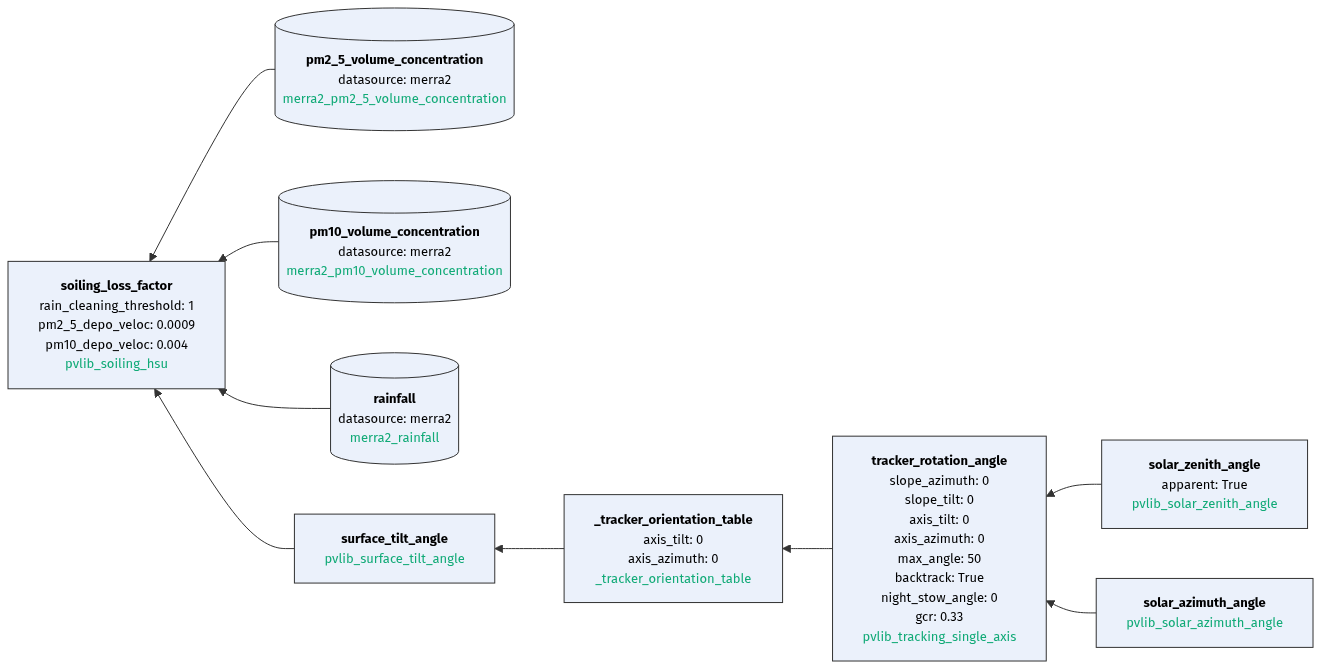

In [15]:
site.profile(pvlib_soiling_hsu).display_flowchart()

## Search for soiling measurements in the PVRADAR Measurement DB

The PVRADAR Measurement DB provides access to a wide range of measurements from locations around the world - soiling, irradiance and more. While this feature is still being finalized, we have already included 9 publicly available soiling measurements for testing purposes. Once finalized, Organizations will be able to organize their internal measurements in a convenient and 100% private manner. 

All currently available measurements originate from the following scientific publication:

Micheli, L., Muller, M. T., Deceglie, M. G., & Ruth, D. (2017). Time Series Analysis of Photovoltaic Soiling Station Data: Version 1.0, August 2017. Office of Scientific and Technical Information (OSTI). https://doi.org/10.2172/1390775

The raw data is available under: https://datahub.duramat.org/dataset/soiling-data.

Note: The exact coordinates of the measurement sites were not disclosed by the authors and have been estimated by PVRADAR. Also, the rainfall data included in the dataset is not based on actual measurements but was retrieved by the authors from the PRISM climate data source.

In [ ]:
site.measurement_table(resource_type=[R.soiling_loss_factor])

# try plotting as a map as well!
#site.measurement_table(resource_type=[R.soiling_loss_factor]).display_map()

,latitude,longitude,start_date,end_date,distance_km,private
id,,,,,,
duramat-1_10,39.137813,-121.941262,2013-02-01,2014-06-01,8.071163,False
duramat-1_4,36.759658,-120.365913,2015-05-18,2016-06-30,306.126194,False
duramat-1_7,35.352351,-120.040062,2015-05-31,2016-07-31,461.520965,False
duramat-1_5A,34.794195,-118.510985,2013-02-01,2015-06-30,578.771760,False
duramat-1_5B,34.794195,-118.510985,2014-07-01,2016-01-01,578.771760,False
duramat-1_16,34.950183,-118.134644,2013-12-01,2014-12-20,582.687077,False
duramat-1_12,33.741627,-117.011362,2014-09-01,2015-08-12,752.036181,False
duramat-1_3,33.144051,-115.496732,2014-12-30,2016-01-01,889.543716,False


In [17]:
# connect to a measurement group
mg = MeasurementGroup('duramat-1_10')

# see list of available measurements
mg.available_measurements

,freq,start_date,end_date
resource_type,,,
rainfall,D,2013-02-01 00:00:00-08:00,2014-06-01 00:00:00-08:00
soiling_loss_factor,D,2013-02-01 00:00:00-08:00,2014-06-01 00:00:00-08:00


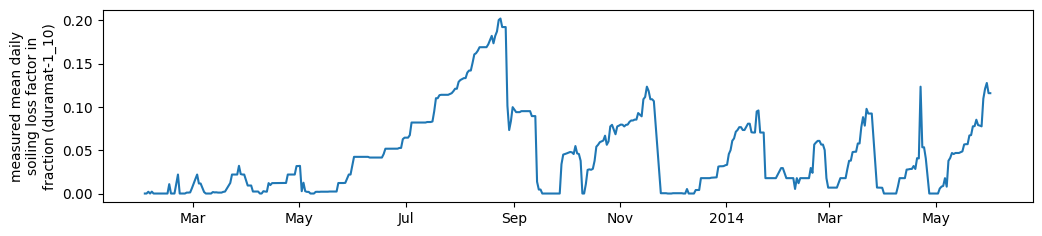

In [18]:
# extract the soiling measurement
meas_soiling = mg.measurement(R.soiling_loss_factor)
resource_plot(meas_soiling)

In [19]:
# see location of measurement group
mg.location

Location: 
  name: None
  latitude: 39.137813
  longitude: -121.941262
  altitude: 26.0
  tz: Etc/GMT+8

## Model soiling losses with HSU for measurement location and default model parameters

In [20]:
soiling_hsu_mg_default = mg.run(pvlib_soiling_hsu, label='soiling from HSU @ measurement location with DEFAULT params')

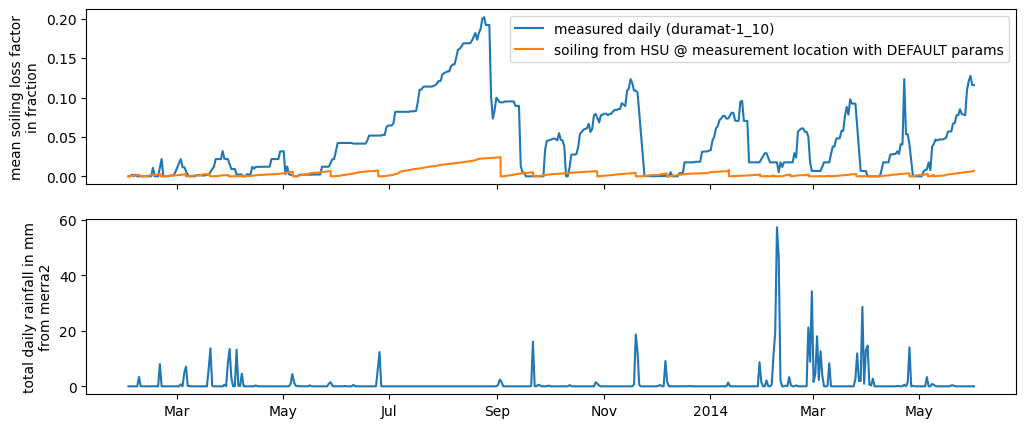

In [21]:
# get rainfall just for plotting
rainfall_mg = mg.resource(R.rainfall(to_freq='D'))

# plot
resource_plot(meas_soiling, soiling_hsu_mg_default, rainfall_mg)

## Fit model parameters to better match measured data

The goal is to find the set of HSU model parameters for which the difference between the model output and the measurement is smallest.

In [22]:
optimal_hsu_params = mg.optimize(
    pvlib_soiling_hsu,
    target=mg.measurement(R.soiling_loss_factor),
    parameters=['rain_cleaning_threshold', 'pm2_5_depo_veloc', 'pm10_depo_veloc']
)
optimal_hsu_params

{'rain_cleaning_threshold': np.float64(3.7553390780578852),
 'pm2_5_depo_veloc': np.float64(0.01065701046205255),
 'pm10_depo_veloc': np.float64(0.045245348601894705)}

In [23]:
soiling_hsu_mg_optimal = mg.run(pvlib_soiling_hsu, **optimal_hsu_params, label='soiling from HSU @ measurement location with OPTIMAL params')

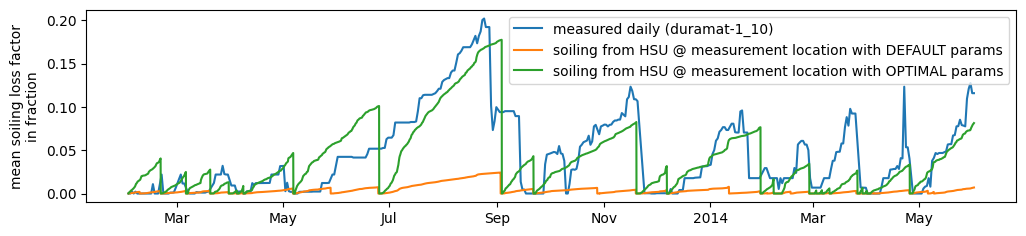

In [24]:
resource_plot(meas_soiling, soiling_hsu_mg_default, soiling_hsu_mg_optimal)

## Apply optimal model parameters to target site

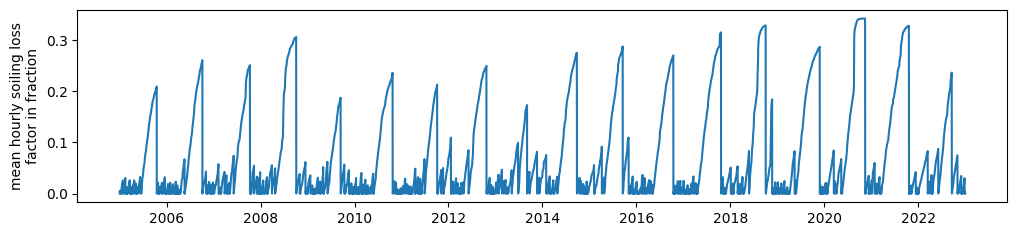

In [25]:
site.interval = '2005..2022'
site_soiling_optimal = site.run(pvlib_soiling_hsu, **optimal_hsu_params)
resource_plot(site_soiling_optimal)

In [26]:
# monthly averages for Pvsyst, PlantPredict and other tools
site_soiling.groupby(site_soiling.index.month).mean()

1     0.001147
2     0.003087
3     0.001371
4     0.002966
5     0.004532
6     0.009757
7     0.018832
8     0.030612
9     0.017770
10    0.004827
11    0.001285
12    0.000705
Name: soiling_loss_factor, dtype: float64

## Estimate soiling energy losses

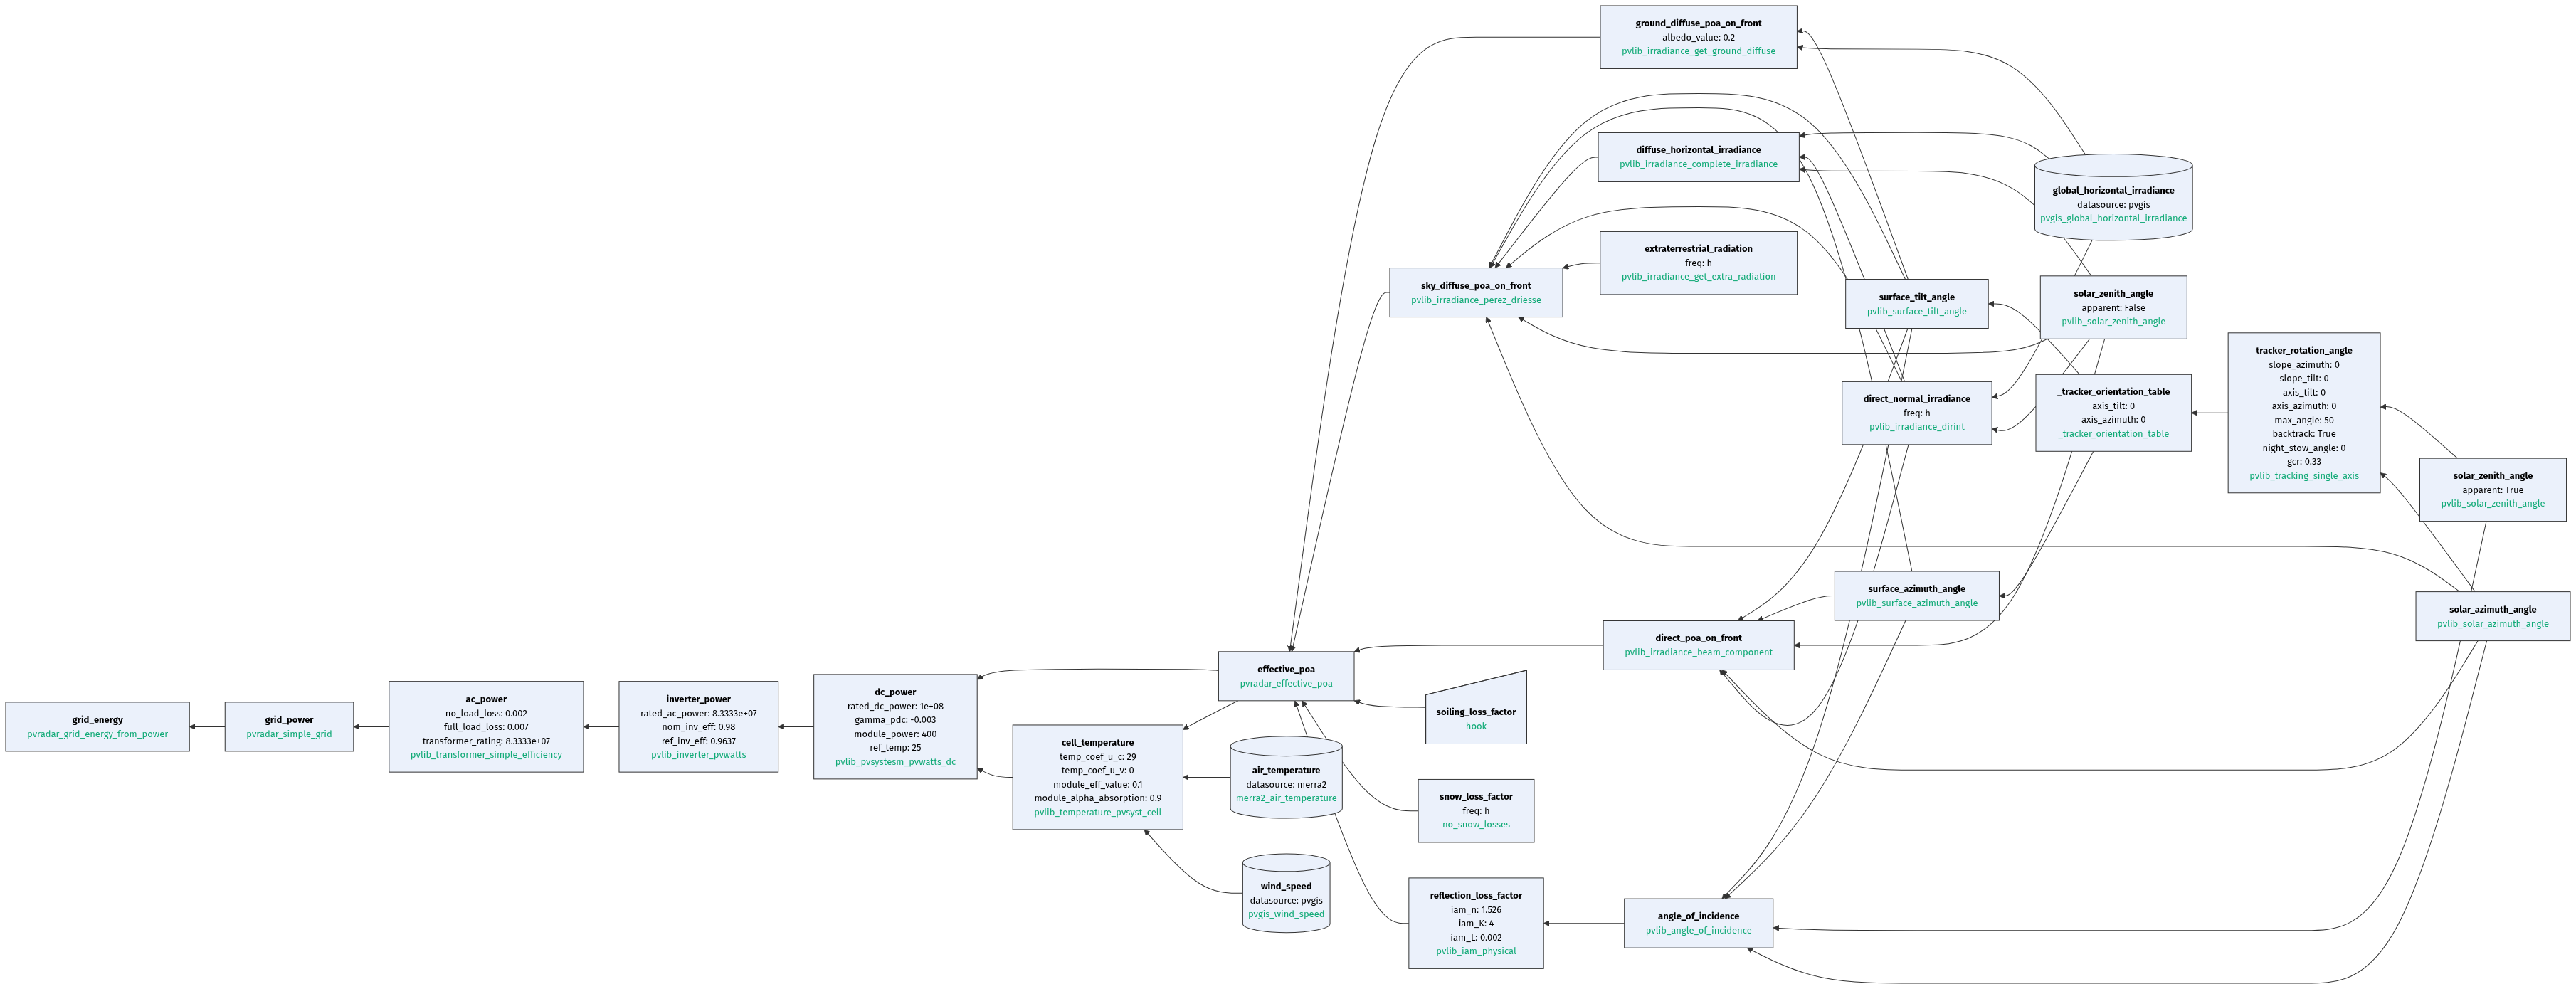

In [27]:
energy_no_soiling = site.resource(R.grid_energy(to_unit='MWh', to_freq='D'), label='energy no soiling')

with site.hooks(for_resource(R.soiling_loss_factor).use(site_soiling_optimal)):
    energy_with_soiling = site.resource(R.grid_energy(to_unit='MWh', to_freq='D'), label='energy with soiling')
    site.profile(R.grid_energy).display_flowchart()

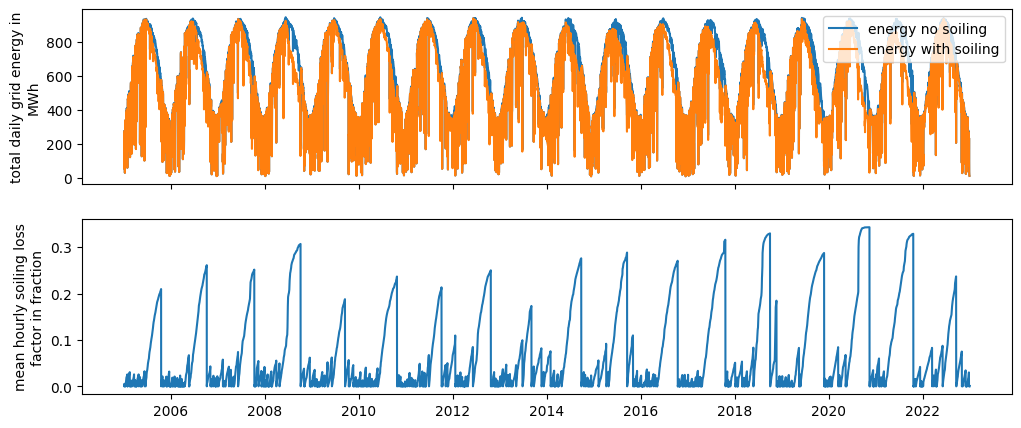

In [28]:
resource_plot(energy_no_soiling, energy_with_soiling, site_soiling_optimal)

# 

# **Why PVRADAR?**

## Model and optimize the real-world behavior of your PV plants

PVRADAR allows you to model the effect of **any technical or environmental factor** on plant performance — not just soiling:
- Combine temperature, soiling, snow, albedo, clipping, and more in a single modeling workflow.
- Quantify impacts in terms of energy yield, PR, LCOE, and financial KPIs.
- Explore what-if scenarios and optimize plant design and O&M strategies.

## Build internal tools and advanced applications

With PVRADAR, you can turn your models into robust, organization-wide tools:
- Build internal web apps that allow colleagues to apply validated models without writing code.
- Standardize modeling across teams and projects.
- Automate reporting and performance analysis to save time and ensure consistency.

## One Python line away from your data

The PVRADAR SDK simplifies data access:
- Seamlessly connect to satellite data, meteo stations, and internal performance databases.
- Standardize and pre-process data for modeling — ready to use in one line of Python.
- Keep full control over your data, whether in the cloud or on-premises.

## Supported by deep expertise

PVRADAR is more than software — it is backed by industry-leading expertise:
- Model validation and tuning with high-quality reference data.
- Consulting and support on temperature losses, O&M optimization, and yield forecasting.
- Proven track record with leading IPPs, developers, and consultants.

👉 **Ready to go further?** [**Contact us to learn how we can help solve your modeling challenge!**](https://pvradar.com/contact)
